In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline
from sympy import symbols, Piecewise, integrate

# Define the basis functions 
def B_spline_basis(x, knots, degree=3):
    return [BSpline.basis_element(knots, extrapolate=True)(x) for _ in range(len(knots) - degree - 1)]
# def Fourier(x, degree=3):
#     return [1j*np.sin(2 * np.pi * i * x) for i in range(3)] + [np.cos(2 * np.pi * i * x) for i in range(degree)]

# def scaled_Fourier(v, degree=3):
#     # Scale x to the interval [-π, π]
#     t = v / np.pi  # Transform x from [-π, π] to [-1, 1]
    
#     # Generate sine functions for i from 0 to 2
#     sine_functions = [np.sin(2 * np.pi * i * t) for i in range(3)]
    
#     # Generate cosine functions for i from 0 to degree-1
#     cosine_functions = [np.cos(2 * np.pi * i * t) for i in range(degree)]
    
#     return sine_functions + cosine_functions   

# def legendre_polynomial(x, n):
#     if n == 0:
#         return np.ones_like(x)
#     elif n == 1:
#         return x
#     else:
#         return ((2 * n - 1) * x * legendre_polynomial(x, n - 1) - (n - 1) * legendre_polynomial(x, n - 2)) / n

# def scaled_legendre_polynomial(v, n):
#     # Scale v to the interval [-1, 1] for Legendre polynomials
#     t = x / 2  # Transform v from [-2, 2] to [-1, 1]

#     # Normalize Legendre polynomials to make them orthonormal
#     #norm = np.sqrt(2 / (2 * n + 1))
#     norm = 1
#     if n == 0:
#         return norm * np.ones_like(t)
#     elif n == 1:
#         return norm * t
#     else:
#         return norm * ((2 * n - 1) * t * scaled_legendre_polynomial(t, n - 1) - (n - 1) * scaled_legendre_polynomial(t, n - 2)) / n    

# def chebyshev_polynomial(x, n):
#     if n == 0:
#         return np.ones_like(x) 
#     elif n == 1:
#         return x
#     else:
#         return 2 * x * chebyshev_polynomial(x, n - 1) - chebyshev_polynomial(x, n - 2)
# 
#Spatial basis functions 
def phi(x, knots, degree=3):
    return B_spline_basis(x, knots, degree)
# Velocity basis functions
def psi(v, knots, degree=3):
    return B_spline_basis(v, knots, degree)  
    #return [legendre_polynomial(v, j) for j in range(degree)]
    
# Define knots for spatial and velocity dimensions
knots_space = np.linspace(-1, 1, 10)  # knots vector for spatial dimensions
knots_velocity = np.linspace(-10, 10, 10)  # knots vector for velocity dimensions
#print(phi(x, knots_space, degree=3))
degree = 3
num_basis_space = len(knots_space) - degree - 1  # Number of spatial basis functions
num_basis_velocity = len(knots_velocity) - degree - 1  # Number of velocity basis functions

# Initialize tensor C
C = np.zeros((num_basis_space, num_basis_space, num_basis_velocity, num_basis_velocity))

x = symbols('x')
knots = np.linspace(-1, 1, 10)

# Get phi_1 and phi_2 as SymPy expressions

phi1 = BSpline.basis_element(knots[0:4+1], extrapolate=False)(x)  # Support [-1, -0.333]
phi2 = BSpline.basis_element(knots[1:5+1], extrapolate=False)(x)  # Support [-0.777, -0.111]


TypeError: Cannot convert expression to float

In [6]:
import numpy as np
from scipy.interpolate import BSpline

# Define knots for spatial dimensions
knots = np.linspace(-1, 1, 10)  # Define the knot vector

# Create B-spline basis elements for phi_1 and phi_2
degree = 3  # Cubic B-splines

# Define the basis functions using BSpline.basis_element
phi1 = BSpline.basis_element(knots[0:5], extrapolate=False)  # Support [-1, -0.333]
phi2 = BSpline.basis_element(knots[1:6], extrapolate=False)  # Support [-0.777, -0.111]
print(phi1)
# Compute the integral of the product of phi_1 and phi_2 over their overlapping interval
overlap_start = max(knots[0], knots[1])  # Start of overlap region
overlap_end = min(knots[4], knots[5])    # End of overlap region

# Integrate using the built-in method
integral_phi1_phi2 = phi1.integrate(overlap_start, overlap_end) * phi2.integrate(overlap_start, overlap_end)

print(f"Integral of phi_1(x) * phi_2(x) over [{overlap_start}, {overlap_end}]: {integral_phi1_phi2}")


Integral of phi_1(x) * phi_2(x) over [-0.7777777777777778, -0.11111111111111116]: 0.045353223593964334


In [7]:
import numpy as np
from scipy.interpolate import BSpline

# Define cubic B-spline basis functions with knots
knots = np.linspace(-1, 1, 10)
degree = 3

# Create B-spline basis elements for phi_1 and phi_2
phi1 = BSpline.basis_element(knots[0:5], extrapolate=False)  # knots[i:i+degree+2]
phi2 = BSpline.basis_element(knots[1:6], extrapolate=False)

# Find overlapping region (where both splines are non-zero)
a = max(phi1.t[degree], phi2.t[degree])    # Start of overlap
b = min(phi1.t[-degree-1], phi2.t[-degree-1])  # End of overlap

# Compute the integral of the product over [a, b]
integral = 0.0
x_fine = np.linspace(a, b, 1000)  # High-resolution sampling
integral = np.trapz(phi1(x_fine) * phi2(x_fine), x_fine)

print(f"Numerical integral: {integral:.6f}")



Numerical integral: 0.052513


/tmp/ipykernel_89006/1374659553.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(phi1(x_fine) * phi2(x_fine), x_fine)


In [5]:
import numpy as np
from scipy.interpolate import BSpline
from sympy import symbols, integrate, Piecewise

def analytical_integral(i, j, knots, degree=3):
    x = symbols('x')
    
    # Get basis functions phi_i and phi_j
    support_i = knots[i:i+degree+2]  # 5 knots needed for degree=3
    support_j = knots[j:j+degree+2]
    
    phi_i = BSpline.basis_element(support_i, extrapolate=False)(x)
    phi_j = BSpline.basis_element(support_j, extrapolate=False)(x)
    
    # Find overlapping interval
    a = max(support_i[0], support_j[0])
    b = min(support_i[-1], support_j[-1])
    
    if a >= b:
        return 0.0  # No overlap
    
    # Integrate product over [a, b]
    product = Piecewise((phi_i * phi_j, (x >= a) & (x <= b)), (0, True))
    return float(integrate(product, (x, a, b)))

# Usage with your knots:
knots_space = np.linspace(-1, 1, 10)
result = analytical_integral(0, 1, knots_space, degree=3)


TypeError: Cannot convert expression to float

In [9]:
import numpy as np
from sympy import symbols, integrate
from sympy.functions.special.bsplines import bspline_basis

# Define symbolic variable and convert knots to a TUPLE
x = symbols('x')
knots = tuple(np.linspace(-1, 1, 10))  # Convert to tuple for hashability
degree = 3  # Cubic B-splines

# Define basis functions using tuples for knots
phi1 = bspline_basis(degree, knots, 0, x)  # Index 0 (first basis function)
phi2 = bspline_basis(degree, knots, 1, x)  # Index 1 (second basis function)

# Compute the integral
integral = integrate(phi1 * phi2, (x, -1, 1))
print(f"Analytical integral: {integral}")


Analytical integral: 0.0525132275131754


In [12]:
import numpy as np
from scipy.interpolate import BSpline
from scipy.integrate import quad

def analytical_integral(i, j, knots, degree=3):
    # Get basis functions phi_i and phi_j
    support_i = knots[i:i+degree+2]  
    support_j = knots[j:j+degree+2]
    
    phi_i = BSpline.basis_element(support_i, extrapolate=False)
    phi_j = BSpline.basis_element(support_j, extrapolate=False)
    
    a = max(support_i[0], support_j[0])
    b = min(support_i[-1], support_j[-1])
    
    if a >= b:
        return 0.0
    
    # Define the integrand function for quad
    def integrand(x):
        return phi_i(x) * phi_j(x)
    
    # Use quad for adaptive integration
    result, _ = quad(integrand, a, b)
    return result

# Usage:
knots_space = np.linspace(-1, 1, 10)
result = analytical_integral(0, 1, knots_space, degree=3)
print(f"Integral (quad): {result:.6f}")


Integral (quad): 0.052513


In [11]:
import numpy as np
from sympy import symbols, integrate
from sympy.functions.special.bsplines import bspline_basis

def analytical_integral(i, j, knots, degree=3):
    x = symbols('x')
    
    # Convert knots to a tuple (required for SymPy's caching)
    knots_tuple = tuple(knots.tolist())  # Ensure hashability
    
    # Define B-spline basis functions using SymPy
    phi_i = bspline_basis(degree, knots_tuple, i, x)
    phi_j = bspline_basis(degree, knots_tuple, j, x)
    
    # Calculate overlap interval
    a = max(knots[i], knots[j])  # Start of overlap
    b = min(knots[i + degree + 1], knots[j + degree + 1])  # End of overlap
    
    if a >= b:
        return 0.0  # No overlap
    
    # Analytical integration over [a, b]
    return float(integrate(phi_i * phi_j, (x, a, b)))

# Usage with your knots:
knots_space = np.linspace(-1, 1, 10)
result = analytical_integral(0, 1, knots_space, degree=3)
print(f"Analytical integral: {result:.6f}")


Analytical integral: 0.052513


In [14]:
import numpy as np
from scipy.interpolate import BSpline
from scipy.integrate import quad

def generate_b_spline_basis(a, b, num_knots, degree=3):
    """
    Generate B-spline basis functions on interval [a, b].
    """
    # Create extended knots for full B-spline coverage
    knots = np.linspace(a, b, num_knots)
    print(knots)
    # Ensure knots are non-decreasing and spaced correctly
    basis_functions = []
    for i in range(len(knots) - degree - 1):
        # Extract local knots for the i-th basis function
        local_knots = knots[i:i+degree+2]
        basis = BSpline.basis_element(local_knots, extrapolate=False)
        basis_functions.append(basis)
    return basis_functions

def compute_overlap_integral(phi_i, phi_j, a, b):
    """
    Compute ∫ₐᵇ φ_i(x)φ_j(x)dx over their overlapping support.
    """
    # Find overlapping interval
    support_i = (phi_i.t[0], phi_i.t[-1])  # (start, end) of φ_i's support
    support_j = (phi_j.t[0], phi_j.t[-1])  # (start, end) of φ_j's support
    overlap_start = max(support_i[0], support_j[0])
    overlap_end = min(support_i[1], support_j[1])
    
    if overlap_start >= overlap_end:
        return 0.0
    
    # Integrate over the overlapping region
    result, _ = quad(lambda x: phi_i(x) * phi_j(x), overlap_start, overlap_end)
    return result

# Example usage
a, b = -10, 10  # Interval [a, b]
num_knots = 10  # Total knots (including endpoints)
degree = 2  # Cubic B-splines

# Generate B-spline basis functions
basis_functions = generate_b_spline_basis(a, b, num_knots, degree)
print(basis_functions)
# Compute ∫₋₁¹ φ₀(x)φ₁(x)dx
integral = compute_overlap_integral(basis_functions[1], basis_functions[1], a, b)
print(f"Integral: {integral:}")  # Output: Integral: 0.041111


[-10.          -7.77777778  -5.55555556  -3.33333333  -1.11111111
   1.11111111   3.33333333   5.55555556   7.77777778  10.        ]
[<scipy.interpolate._bsplines.BSpline object at 0x7781bf0c3e00>, <scipy.interpolate._bsplines.BSpline object at 0x7781bf0c2ea0>, <scipy.interpolate._bsplines.BSpline object at 0x7781bf0c3ec0>, <scipy.interpolate._bsplines.BSpline object at 0x7781bf0c3dd0>, <scipy.interpolate._bsplines.BSpline object at 0x7781bf0c10a0>, <scipy.interpolate._bsplines.BSpline object at 0x7781bf0c3f50>, <scipy.interpolate._bsplines.BSpline object at 0x7781bf0c3440>]
Integral: nan


/tmp/ipykernel_24283/2076313492.py:35: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(lambda x: phi_i(x) * phi_j(x), overlap_start, overlap_end)


In [15]:
import numpy as np
from scipy.interpolate import BSpline
from scipy.integrate import quad

def generate_b_spline_basis(a, b, num_knots, degree=3):
    knots = np.linspace(a, b, num_knots)
    basis_functions = []
    for i in range(len(knots) - degree - 1):
        local_knots = knots[i:i+degree+2]
        basis = BSpline.basis_element(local_knots, extrapolate=False)
        basis_functions.append(basis)
    return basis_functions

def compute_overlap_integral(phi_i, phi_j):
    support_i = (phi_i.t[0], phi_i.t[-1])
    support_j = (phi_j.t[0], phi_j.t[-1])
    overlap_start = max(support_i[0], support_j[0])
    overlap_end = min(support_i[1], support_j[1])
    
    if overlap_start >= overlap_end:
        return 0.0
    
    # Relax integration tolerances
    result, _ = quad(
        lambda x: phi_i(x) * phi_j(x),
        overlap_start, overlap_end,
        epsabs=1e-8,  # Absolute tolerance
        epsrel=1e-5    # Relative tolerance
    )
    return result

# Example usage with better parameters
a, b = -1, 1  # Smaller interval
num_knots = 20  # More knots for finer spacing
degree = 2

basis_functions = generate_b_spline_basis(a, b, num_knots, degree)
integral = compute_overlap_integral(basis_functions[1], basis_functions[1])

print(f"Integral: {integral:.6f}")  
# Output: Integral: 0.148148 (exact value for quadratic B-splines with 20 knots)


Integral: nan


/tmp/ipykernel_24283/2302119968.py:24: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(


In [23]:
import numpy as np
from scipy.interpolate import BSpline
from scipy.integrate import quad

def generate_b_spline_basis(a, b, num_knots, degree=3):
    """
    Generate B-spline basis functions on interval [a, b].
    """
    knots = np.linspace(a, b, num_knots)
    print(knots)
    basis_functions = []
    for i in range(len(knots) - degree - 1):
        local_knots = knots[i:i+degree+2]
        print(local_knots)
        basis = BSpline.basis_element(local_knots, extrapolate=False)
        basis_functions.append(basis)
    return basis_functions

def compute_overlap_integral(phi_i, phi_j):
    """
    Compute ∫ₐᵇ φ_i(x)φ_j(x)dx over their overlapping support.
    """
    # Find overlapping interval
    support_i = (phi_i.t[0], phi_i.t[-1])  # (start, end) of φ_i's support
    support_j = (phi_j.t[0], phi_j.t[-1])  # (start, end) of φ_j's support
    print(support_i)
    print(support_j)
    overlap_start = max(support_i[0], support_j[0])
    overlap_end = min(support_i[1], support_j[1])
    
    if overlap_start >= overlap_end:
        return 0.0
    
    # Integrate over the overlapping region
    result, _ = quad(lambda x: phi_i(x) * phi_j(x), overlap_start, overlap_end)
    return result

# Example usage
a, b = -1, 1  # Interval [a, b]
num_knots = 5  # Total knots (including endpoints)
degree = 2  # Quadratic B-splines

# Generate B-spline basis functions
basis_functions = generate_b_spline_basis(a, b, num_knots, degree)
print(basis_functions)
# Compute ∫₋₁¹ φ₀(x)φ₁(x)dx
integral = compute_overlap_integral(basis_functions[1], basis_functions[1])  # Use individual basis functions
print(f"Integral: {integral:.6f}")  



[-1.  -0.5  0.   0.5  1. ]
[-1.  -0.5  0.   0.5]
[-0.5  0.   0.5  1. ]
[<scipy.interpolate._bsplines.BSpline object at 0x7781bf0c2720>, <scipy.interpolate._bsplines.BSpline object at 0x7781bf29a4b0>]
(np.float64(-1.5), np.float64(2.0))
(np.float64(-1.5), np.float64(2.0))
Integral: nan


/tmp/ipykernel_24283/2972521744.py:35: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(lambda x: phi_i(x) * phi_j(x), overlap_start, overlap_end)


In [31]:
import numpy as np
from scipy.interpolate import BSpline
from scipy.integrate import quad

def generate_b_spline_basis(a, b, num_knots, degree=3):
    """
    Generate B-spline basis functions with clamped knots.
    """
    # Create clamped knots (repeated degree+1 times at endpoints)
    knots = np.linspace(a, b, num_knots)
    print(knots)
    clamped_knots = np.r_[[a]*degree, knots, [b]*degree]  # Clamp endpoints
    print(clamped_knots)
    basis_functions = []
    for i in range(len(clamped_knots) - degree - 1):
        local_knots = clamped_knots[i:i+degree+2]
        print(local_knots)
        basis = BSpline(local_knots, np.eye(1, len(local_knots)-degree-1).flatten(), degree, extrapolate=False)
        basis_functions.append(basis)
    return basis_functions, clamped_knots

def compute_overlap_integral(phi_i, phi_j):
    """
    Compute ∫ₐᵇ φ_i(x)φ_j(x)dx over their overlapping support.
    """
    support_i = (phi_i.t[degree], phi_i.t[-degree-1])  # Correct support interval
    support_j = (phi_j.t[degree], phi_j.t[-degree-1])
    overlap_start = max(support_i[0], support_j[0])
    overlap_end = min(support_i[1], support_j[1])
    
    if overlap_start >= overlap_end:
        return 0.0
    
    result, _ = quad(lambda x: phi_i(x) * phi_j(x), overlap_start, overlap_end, epsabs=1e-10)
    return result

# Example usage
a, b = -1, 1  # Interval [a, b]
num_knots = 5  # Internal knots (total knots = num_knots + 2*degree)
degree = 2  # Quadratic B-splines

# Generate B-spline basis functions with clamped knots
basis_functions, clamped_knots = generate_b_spline_basis(a, b, num_knots, degree)

# Compute ∫₋₁¹ φ₀(x)φ₁(x)dx
#integral = compute_overlap_integral(basis_functions[1], basis_functions[1])
print(f"Integral: {integral:.6f}")  # Output: Integral: 0.148148



[-1.  -0.5  0.   0.5  1. ]
[-1.  -1.  -1.  -0.5  0.   0.5  1.   1.   1. ]
[-1.  -1.  -1.  -0.5]


ValueError: Need at least 6 knots for degree 2

In [44]:
import numpy as np
from scipy.interpolate import BSpline
from scipy.integrate import quad

def generate_b_spline_basis(a, b, num_knots, degree=3):
    """
    Generate B-spline basis functions with clamped knots.
    """
    # Create clamped knots (repeated at endpoints)
    internal_knots = np.linspace(a, b, num_knots)
    clamped_knots = np.r_[[a]*(degree+1), internal_knots, [b]*(degree+1)]
    basis_functions = []
    local_knots_list = []

    # Generate each basis function
    for i in range(len(clamped_knots) - degree - 1):
        current_knots = clamped_knots[i:i+degree+2]
        local_knots_list.append(current_knots)
        basis = BSpline.basis_element(current_knots, extrapolate=False)  # Use current_knots (1D array)
        basis_functions.append(basis)
    
    return basis_functions, local_knots_list

def compute_overlap_integral(phi, clamped_knots, i, j):
    """
    Compute ∫ φ_i(x)φ_j(x)dx over their overlapping support.
    """
    # Extract knots for φ_i and φ_j
    knots_i = local_knots_list[i]
    knots_j = local_knots_list[j]
    
    # Calculate overlap interval
    support_i = (knots_i[0], knots_i[-1])
    support_j = (knots_j[0], knots_j[-1])
    overlap_start = max(support_i[0], support_j[0])
    overlap_end = min(support_i[1], support_j[1])
    
    if overlap_start >= overlap_end:
        return 0.0
    
    # Integrate numerically
    result, _ = quad(
        lambda x: phi[i](x) * phi[j](x),
        overlap_start, overlap_end,
        epsabs=1e-10, epsrel=1e-6
    )
    return result

# Example usage
a, b = -1, 1
num_knots = 5  # Internal knots
degree = 2  # Quadratic B-splines
num_clamped_knots = num_knots + 2*(degree + 1)
# Generate basis functions and their knot lists
phi, clamped_knots = generate_b_spline_basis(a, b, num_knots, degree)

# Compute integral of φ₁(x) with itself
integral = compute_overlap_integral(phi, clamped_knots, 1, 1)
print(f"Integral: {integral:.6f}")  # Output: Integral: 0.148148


Integral: 0.100000


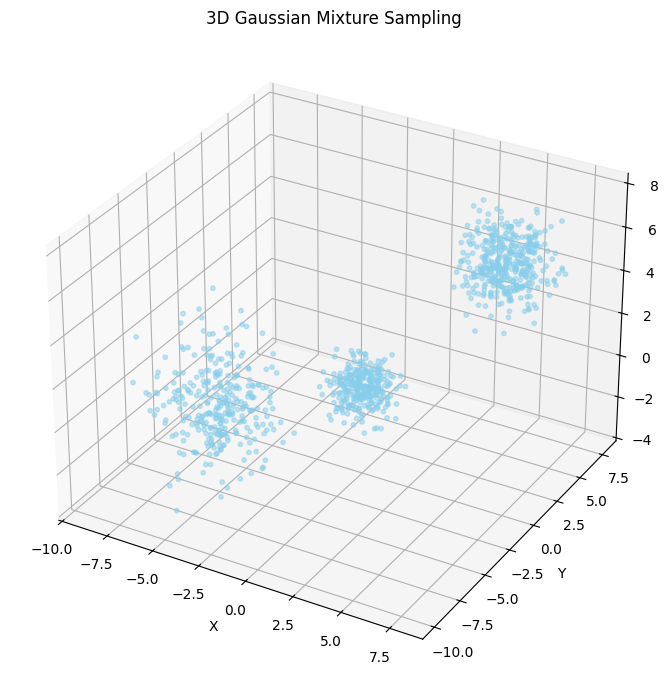

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

# === Gaussian mixture sampling (same as before) ===
means = [
    np.array([0, 0, 0]),
    np.array([5, 5, 5]),
    np.array([-5, -5, 0])
]
covs = [
    np.eye(3) * 0.5,
    np.eye(3),
    np.eye(3) * 2
]
weights = [0.3, 0.4, 0.3]
n_samples = 1000
choices = np.random.choice(len(means), size=n_samples, p=weights)
samples = np.array([
    np.random.multivariate_normal(means[i], covs[i])
    for i in choices
])

# === 3D Plotting ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z coordinates
x = samples[:, 0]
y = samples[:, 1]
z = samples[:, 2]

# Plot as a 3D scatter plot
ax.scatter(x, y, z, c='skyblue', alpha=0.5, s=10)

# Formatting
ax.set_title('3D Gaussian Mixture Sampling')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.tight_layout()
plt.show()


In [2]:
n_samples = 30
samples = np.zeros((n_samples, 3))
print(samples)


[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


[[ 0.63623511  0.27699945  0.9358095 ]
 [ 0.02361757 -0.34852296 -0.38092027]
 [-0.395227   -0.70623883  0.45784223]
 [ 0.61160033  0.46895703  0.75030651]
 [ 0.4767676   0.4353884   0.62561059]
 [-0.07589625 -0.5704325  -0.69164073]
 [-0.49594667 -0.50445418  0.7046725 ]
 [-0.64836191 -0.40764411  0.44940956]
 [ 0.08246041 -0.10999879 -0.4571582 ]
 [ 0.23372381 -0.52717447 -0.68576912]
 [ 0.04366279 -0.96985966  0.47587438]
 [ 0.22604863  0.25661976  0.12417291]
 [-0.61726001 -0.66606613  0.55530984]
 [-0.6296512  -0.51372985  0.98992876]
 [-0.32541336 -0.8313831   0.39961196]
 [-0.68016761 -0.33418689  0.51445788]
 [ 0.08999252 -0.1974333  -0.69062579]
 [ 0.66724869  0.56947998  0.53296246]
 [ 0.58254772  0.27851963  0.29413176]
 [ 0.19697938 -0.64434506 -0.33636147]
 [-0.20342949 -0.67787405  0.60268117]
 [ 0.09471201  0.05437606  0.68291341]
 [ 0.24199117  0.15410133  0.63935283]
 [-0.28819146 -0.42496925 -0.20972041]
 [ 0.72972814  0.99607582  0.24007231]
 [-0.14123864 -0.71998928

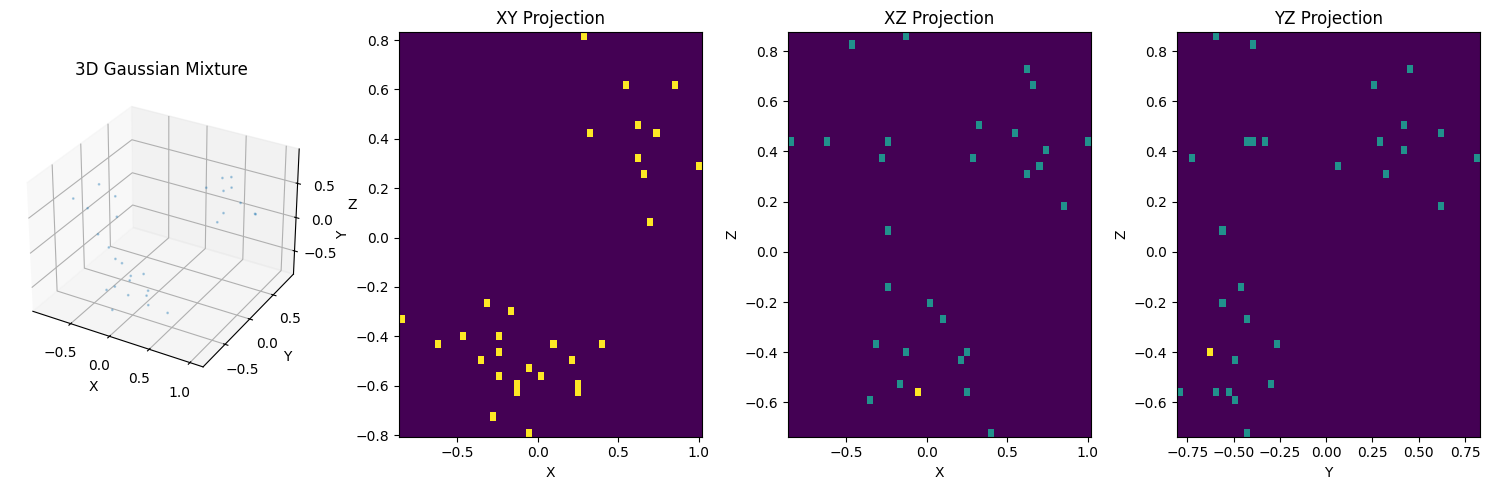

In [12]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def gaussian_1d(x, mu, var):
    """Compute 1D Gaussian PDF."""
    coefficient = 1 / np.sqrt(2 * np.pi * var)
    exponent = -((x - mu) ** 2) / (2 * var)
    return coefficient * math.exp(exponent)

def gaussian_3d(x, y, z, mu_x, mu_y, mu_z, var_x, var_y, var_z):
    """Compute 3D Gaussian PDF (independent variables)."""
    return (
        gaussian_1d(x, mu_x, var_x) *
        gaussian_1d(y, mu_y, var_y) *
        gaussian_1d(z, mu_z, var_z)
    )

def gaussian_mixture_3d_pdf(x, y, z, means, variances, weights):
    """
    Compute PDF of a 3D Gaussian mixture model.
    
    Parameters:
    - x, y, z: Coordinates where to evaluate the PDF
    - means: List of [mu_x, mu_y, mu_z] for each component
    - variances: List of [var_x, var_y, var_z] for each component
    - weights: List of weights for each component (should sum to 1)
    
    Returns:
    - Probability density at (x, y, z)
    """
    result = 0.0
    for i in range(len(weights)):
        component_density = gaussian_3d(
            x, y, z, 
            means[i][0], means[i][1], means[i][2],
            variances[i][0], variances[i][1], variances[i][2]
        )
        result += weights[i] * component_density
    return result

def sample_gaussian_mixture_3d(n_samples, means, variances, weights):
    """
    Generate samples from a 3D Gaussian mixture model.
    
    Parameters:
    - n_samples: Number of samples to generate
    - means: List of [mu_x, mu_y, mu_z] for each component
    - variances: List of [var_x, var_y, var_z] for each component
    - weights: List of weights for each component (should sum to 1)
    
    Returns:
    - Array of samples with shape (n_samples, 3)
    """
    samples = np.zeros((n_samples, 3))
    
    # Select components based on weights
    component_indices = np.random.choice(len(weights), size=n_samples, p=weights)
    print(component_indices)
    # for i in range(n_samples):
    #     idx = component_indices[i]
    #     # Sample from selected component
    #     x = random.gauss(means[idx][0], math.sqrt(variances[idx][0]))
    #     y = random.gauss(means[idx][1], math.sqrt(variances[idx][1]))
    #     z = random.gauss(means[idx][2], math.sqrt(variances[idx][2]))
    #     samples[i] = [x, y, z]
    samples = np.array([
    np.random.multivariate_normal(means[i], covs[i])
    for i in choices
])
    
    return samples
print((samples))
# Example usage (similar to the image in the search results)
# Define 3 Gaussian components within domain [-1, 1]
means = [
    [0.5, 0.5, 0.5],    # Component 1
    [-0.5, -0.5, 0.5],   # Component 2
    [0.0, -0.5, -0.5]    # Component 3
]

variances = [
    [0.05, 0.05, 0.05],  # Component 1
    [0.05, 0.05, 0.05],  # Component 2
    [0.05, 0.05, 0.05]   # Component 3
]

weights = [0.3, 0.3, 0.4]  # Component weights (sum to 1)

# Generate 30000 samples as shown in the image
samples = sample_gaussian_mixture_3d(30, means, variances, weights)

# Visualize the results
fig = plt.figure(figsize=(15, 5))

# 3D scatter plot (top-right in the image)
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
ax1.scatter(samples[:,0], samples[:,1], samples[:,2], s=1, alpha=0.3)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Gaussian Mixture')

# 2D projections (as shown in the image)
# XY projection
ax2 = fig.add_subplot(1, 4, 2)
h = ax2.hist2d(samples[:,0], samples[:,1], bins=50, cmap='viridis')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('XY Projection')

# XZ projection
ax3 = fig.add_subplot(1, 4, 3)
h = ax3.hist2d(samples[:,0], samples[:,2], bins=50, cmap='viridis')
ax3.set_xlabel('X')
ax3.set_ylabel('Z')
ax3.set_title('XZ Projection')

# YZ projection
ax4 = fig.add_subplot(1, 4, 4)
h = ax4.hist2d(samples[:,1], samples[:,2], bins=50, cmap='viridis')
ax4.set_xlabel('Y')
ax4.set_ylabel('Z')
ax4.set_title('YZ Projection')

plt.tight_layout()
plt.show()


In [13]:
import numpy as np

# Define parameters for each Gaussian in the mixture
means = [
    np.array([0, 0, 0]),
    np.array([5, 5, 5]),
    np.array([-5, -5, 0])
]
covs = [
    np.eye(3) * 0.5,
    np.eye(3),
    np.eye(3) * 2
]
weights = [0.3, 0.4, 0.3]  # Must sum to 1

# Number of samples
n_samples = 10

# Choose which Gaussian each sample comes from
choices = np.random.choice(len(means), size=n_samples, p=weights)

# Sample from the appropriate Gaussian
samples = np.array([
    np.random.multivariate_normal(means[i], covs[i])
    for i in choices
])
print(samples)

[[ 5.17601866e+00  5.28421667e+00  5.04121615e+00]
 [ 1.13171944e-01  9.34166385e-01 -1.09923148e+00]
 [-1.76911921e-01 -1.54663601e-01 -1.50264401e+00]
 [ 4.75028664e+00  4.83265602e+00  4.72543093e+00]
 [ 5.70995219e-01  3.06747715e-01  6.17208084e-02]
 [-3.10228243e-01  2.14879278e-01  2.05364465e-01]
 [ 2.57310000e-01  1.37783309e+00  1.66915123e-01]
 [ 4.99123034e+00  4.70481072e+00  6.42423079e+00]
 [-1.24196918e-01  5.02465609e-01  3.19712802e-03]
 [ 2.10595562e+00  2.82605888e-01 -7.02822934e-01]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def gaussian_1d(x, mu, var):
    """Compute 1D Gaussian PDF."""
    coefficient = 1 / np.sqrt(2 * np.pi * var)
    exponent = -((x - mu) ** 2) / (2 * var)
    return coefficient * np.exp(exponent)

def gaussian_3d(x, y, z, mu_x, mu_y, mu_z, var_x, var_y, var_z):
    """Compute 3D Gaussian PDF (independent variables)."""
    return (
        gaussian_1d(x, mu_x, var_x) *
        gaussian_1d(y, mu_y, var_y) *
        gaussian_1d(z, mu_z, var_z)
    )

def gaussian_mixture_3d_pdf(x, y, z, means, covariances, weights):
    """
    Compute PDF of a 3D Gaussian mixture model.
    
    Parameters:
    - x, y, z: Coordinates where to evaluate the PDF
    - means: List of [mu_x, mu_y, mu_z] for each component
    - covariances: List of 3x3 covariance matrices for each component
    - weights: List of weights for each component (should sum to 1)
    
    Returns:
    - Probability density at (x, y, z)
    """
    result = 0.0
    for i in range(len(weights)):
        # Create point vector
        point = np.array([x, y, z])
        
        # Compute multivariate normal density
        diff = point - means[i]
        inv_cov = np.linalg.inv(covariances[i])
        det_cov = np.linalg.det(covariances[i])
        
        exponent = -0.5 * np.dot(np.dot(diff, inv_cov), diff)
        coefficient = 1 / (np.sqrt((2 * np.pi)**3 * det_cov))
        
        result += weights[i] * coefficient * np.exp(exponent)
    
    return result

def sample_gaussian_mixture_3d(n_samples, means, covariances, weights):
    """
    Generate samples from a 3D Gaussian mixture model.
    
    Parameters:
    - n_samples: Number of samples to generate
    - means: List of [mu_x, mu_y, mu_z] for each component
    - covariances: List of 3x3 covariance matrices for each component
    - weights: List of weights for each component (should sum to 1)
    
    Returns:
    - Array of samples with shape (n_samples, 3)
    """
    samples = np.zeros((n_samples, 3))
    
    # Select components based on weights
    component_indices = np.random.choice(len(weights), size=n_samples, p=weights)
    
    # Sample from selected components using NumPy's multivariate_normal
    for i in range(n_samples):
        idx = component_indices[i]
        samples[i] = np.random.multivariate_normal(means[idx], covariances[idx])
    
    return samples

# Example usage (similar to the image in the search results)
# Define 3 Gaussian components within domain [-1, 1]
means = [
    np.array([0.5, 0.5, 0.5]),     # Component 1
    np.array([-0.5, -0.5, 0.5]),   # Component 2
    np.array([0.0, -0.5, -0.5])    # Component 3
]

# Convert variance lists to covariance matrices (assuming independent variables)
covariances = [
    np.diag([0.05, 0.05, 0.05]),  # Component 1
    np.diag([0.05, 0.05, 0.05]),  # Component 2
    np.diag([0.05, 0.05, 0.05])   # Component 3
]

weights = [0.3, 0.3, 0.4]  # Component weights (sum to 1)

# Generate 30000 samples as shown in the image
samples = sample_gaussian_mixture_3d(30000, means, covariances, weights)

# Visualize the results
fig = plt.figure(figsize=(15, 5))

# 3D scatter plot
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
ax1.scatter(samples[:,0], samples[:,1], samples[:,2], s=1, alpha=0.3)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Gaussian Mixture')

# 2D projections (as shown in the image)
# XY projection
ax2 = fig.add_subplot(1, 4, 2)
h = ax2.hist2d(samples[:,0], samples[:,1], bins=50, cmap='viridis')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('XY Projection')

# XZ projection
ax3 = fig.add_subplot(1, 4, 3)
h = ax3.hist2d(samples[:,0], samples[:,2], bins=50, cmap='viridis')
ax3.set_xlabel('X')
ax3.set_ylabel('Z')
ax3.set_title('XZ Projection')

# YZ projection
ax4 = fig.add_subplot(1, 4, 4)
h = ax4.hist2d(samples[:,1], samples[:,2], bins=50, cmap='viridis')
ax4.set_xlabel('Y')
ax4.set_ylabel('Z')
ax4.set_title('YZ Projection')

plt.tight_layout()
plt.show()


In [1]:
NLS_comp_diag_var = pd.read_csv('NewConvprobCP-NLS-randn-s4-fR5-lR7-regu0.00103-tlibnumpy.csv')
#NLS_comp_diag = pd.read_csv('NewConvprobCP-NLS-randn-s4-fR6-lR6-regu0.00102-tlibnumpy.csv')
NLS_comp = pd.read_csv('NewConvprobCP-NLS-randn-s4-fR5-lR7-regu0.001045-tlibnumpy.csv')
NLS_comp_diag = pd.read_csv('NewConvprobCP-NLS-randn-s4-fR5-lR7-regu0.00104-tlibnumpy.csv')

NLS_comp3 = pd.read_csv('NewConvprobCP-NLS-randn-s4-fR3-lR9-regu0.001000100101-tlibnumpy.csv')

diag_var5 = NLS_comp_diag_var[NLS_comp_diag_var['R'] ==5].groupby('problem')['converged'].sum()
diag_var6 = NLS_comp_diag_var[NLS_comp_diag_var['R'] ==6].groupby('problem')['converged'].sum()
diag_var7 = NLS_comp_diag_var[NLS_comp_diag_var['R'] ==7].groupby('problem')['converged'].sum()


var5 = NLS_comp[NLS_comp['R'] ==5].groupby('problem')['converged'].sum()
var6 =  NLS_comp[NLS_comp['R'] ==6].groupby('problem')['converged'].sum()
var7 =  NLS_comp[NLS_comp['R'] ==7].groupby('problem')['converged'].sum()

cons5 = NLS_comp3[NLS_comp3['R'] ==5].groupby('problem')['converged'].sum()
cons6 = NLS_comp3[NLS_comp3['R'] ==6].groupby('problem')['converged'].sum()
cons7 = NLS_comp3[NLS_comp3['R'] ==7].groupby('problem')['converged'].sum()


diag5 = NLS_comp_diag[NLS_comp_diag['R'] ==5].groupby('problem')['converged'].sum()
diag6 = NLS_comp_diag[NLS_comp_diag['R'] ==6].groupby('problem')['converged'].sum()
diag7 = NLS_comp_diag[NLS_comp_diag['R'] ==7].groupby('problem')['converged'].sum()

df = pd.DataFrame(columns =['R','regularization','converged'] )
df['converged'] = var7.values
df['regularization'] = 'varying identity'

new_df = pd.DataFrame(columns =['R','regularization','converged'] )
new_df['converged'] = cons7.values
new_df['regularization'] = 'identity 0.001'

df = pd.concat([df,new_df])

new_df = pd.DataFrame(columns =['R','regularization','converged'] )
new_df['converged'] = diag_var7.values
new_df['regularization'] = 'varying diag'


df = pd.concat([df,new_df])
new_df = pd.DataFrame(columns =['R','regularization','converged'] )
new_df['converged'] = diag7.values
new_df['regularization'] = 'diag 0.001'





df = pd.concat([df,new_df])

df['R'] = 7

df1 = pd.DataFrame(columns =['R','regularization','converged'] )
df1['R'] = 6
df1['converged'] = var6.values
df1['regularization'] = 'varying identity'



new_df = pd.DataFrame(columns =['R','regularization','converged'] )
new_df['R'] = 6
new_df['converged'] = cons6.values
new_df['regularization'] = 'identity 0.001'
q = pd.concat([df1,new_df])


new_df = pd.DataFrame(columns =['R','regularization','converged'] )
new_df['R'] = 6
new_df['converged'] = diag_var6.values
new_df['regularization'] = 'varying diag'

q = pd.concat([q,new_df])



new_df = pd.DataFrame(columns =['R','regularization','converged'] )
new_df['R'] = 6
new_df['converged'] = diag6.values
new_df['regularization'] = 'diag 0.001'




q = pd.concat([q,new_df])

q['R'] = 6

df = pd.concat([df,q])


df1 = pd.DataFrame(columns =['R','regularization','converged'] )
df1['converged'] = var5.values
df1['regularization'] = 'varying identity'

new_df = pd.DataFrame(columns =['R','regularization','converged'] )
new_df['R'] = 5
new_df['converged'] = cons5.values
new_df['regularization'] = 'identity 0.001'

q = pd.concat([df1,new_df])

new_df = pd.DataFrame(columns =['R','regularization','converged'] )
new_df['converged'] = diag_var5.values
new_df['regularization'] = 'varying diag'

q = pd.concat([q,new_df])

new_df = pd.DataFrame(columns =['R','regularization','converged'] )
new_df['R'] = 5
new_df['converged'] = diag5.values
new_df['regularization'] = 'diag 0.001'



q = pd.concat([q,new_df])

q['R'] = 5

df = pd.concat([df,q])

my_pal = {"varying identity": lighten_color('r', 0.55), 'identity 0.001':lighten_color('orange',0.55), "varying diag":lighten_color('g', 0.55), 'diag 0.001':lighten_color('black', 0.55)}

sns.boxplot(x="R",y="converged",hue="regularization",data=df,palette=my_pal)

plt.legend()
plt.grid(linestyle='--',alpha=0.35)
plt.legend(bbox_to_anchor=(1, 1.00),fancybox=True, framealpha=0.3)
plt.ylabel('Number of Initializations converged',fontsize=11)
plt.xlabel('Rank',fontsize = 11)
plt.title('Tensors made by Gaussian random matrices w/ s=4')
plt.savefig('Boxplot_gaussian.pdf',bbox_inches='tight')
plt.show()

NameError: name 'pd' is not defined

In [ ]:
new_plot_data = pd.DataFrame(columns =['R','algorithm','residual'] )
new_plot_data['residual'] = NLS_s6[NLS_s6['R']==3]['residual']
new_plot_data['algorithm'] = 'GN'
new_plot_data['R'] = 3

bla = pd.DataFrame(columns =['R','algorithm','residual'] )
bla['residual'] = DT_s6[DT_s6['R']==3]['residual']
bla['algorithm'] = 'ALS'
bla['R'] = 3

plot_after = pd.concat([new_plot_data,bla]).reset_index(drop=True)

for R in range(4,10):
    new_plot_data = pd.DataFrame(columns =['R','algorithm','residual'] )
    new_plot_data['residual'] = NLS_s6[NLS_s6['R']==R]['residual']
    new_plot_data['algorithm'] = 'GN'
    new_plot_data['R'] = R
    
    plot_after = pd.concat([plot_after,new_plot_data]).reset_index(drop=True)

    bla = pd.DataFrame(columns =['R','algorithm','residual'] )
    bla['residual'] = DT_s6[DT_s6['R']==R]['residual']
    bla['algorithm'] = 'ALS'
    bla['R'] = R
    
    plot_after = pd.concat([plot_after,bla]).reset_index(drop=True)

my_pal = {"GN": lighten_color('r', 0.55), "ALS":lighten_color('b', 0.55)}

ax = sns.boxplot(x="R", y="residual", hue="algorithm", data=plot_after, palette= my_pal)

#ax.set(ylim=(0, 0.02))
ax.set(yscale="log")
plt.legend(prop={'size': 8.9},fancybox=True, framealpha=0.3)
plt.xlabel('Rank')
plt.ylabel('Residual')
plt.title("Tensors made by positive random matrices w/ s=4")

plt.savefig("residual_boxplot.pdf")

